# HW 15 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 9th, 2025 at 11:59pm** on Gradescope

## 1 Modify the Animation from Lecture
Modify the given sine wave animation so that the wave moves twice as fast. What parts of the code you you need to change, and why? Please specifically highlight this in your code

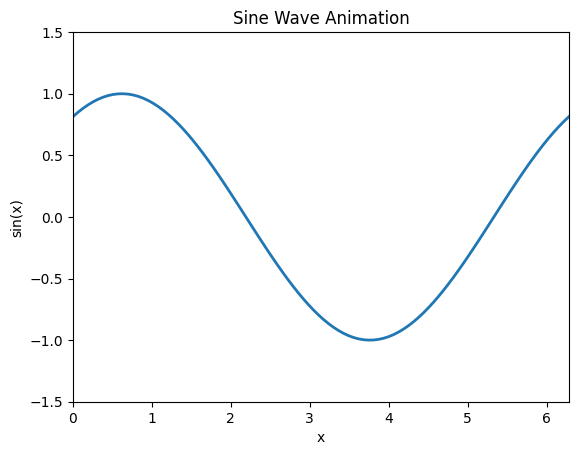

In [4]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


fig, ax = plt.subplots()
ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(-1.5, 1.5)
line, = ax.plot([], [], lw=2)

def init():
    line.set_data([], [])
    return line,

#animation
def animate(frame):
    x = np.linspace(0, 2 * np.pi, 100)
    y = np.sin(x + 0.2 * frame)
    line.set_data(x, y)
    return line,

ani = animation.FuncAnimation(fig, animate, init_func=init, frames=100, interval=10)
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.title('Sine Wave Animation')

#save
ani.save('sine_wave_animation.gif', writer='pillow')
plt.show()


In [5]:
# Your comment here
# I used the same code but incresed the speed with the frame increment

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [8]:
# Your code here
# I saved it initially so that it was viewable

Explain what happens if you set `blit=True` in `FuncAnimation`? What happens if you set it to `blit=False`?

In [9]:
# Your comment here
#blit=True means that it only redraws the parts that change, which makes it run faster
#blit=False means at every frame, the plot is redrawn

## 2 A Different Animation
Write an animation where a dot moves in a circular path instead of sine wave. *Hint: You will need to use `np.sin` and `np.cos`. 

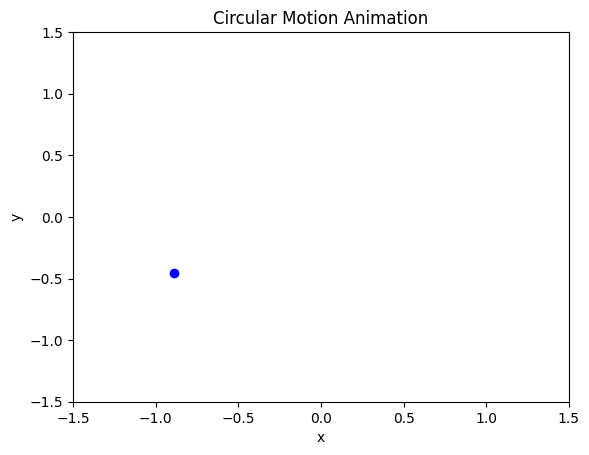

In [15]:

fig, ax = plt.subplots()
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
dot, = ax.plot([], [], 'bo')

#initialize
def init():
    dot.set_data([], [])
    return dot,

#animation
def animate(frame):
    x = [np.cos(0.1 * frame)]
    y = [np.sin(0.1 * frame)]
    dot.set_data(x, y)
    return dot,

ani = animation.FuncAnimation(fig, animate, init_func=init, frames=100, interval=20, blit=True)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Circular Motion Animation')

#save as gif
ani.save('circular_motion_animation.gif', writer='pillow')
plt.show()


Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [14]:
# Your code here
#It is part of the above code!

## 3 Simulate Orbital Motion of Planets and a Comet
**Check out the `example_solar_system_animation.mp4` as an example of what you will be creating in this problem.**

Now you will simulate and visualize the orbital motion of Earth, Mars and a coment around the Sun using Newtonian gravity and Python. Here are the steps:
* Calculate the gravitational forces acting on each body.
* Update positions and velocities over time.
* Simulate the motion of these celestial bodies over a period of 5 years.
* Animate the results to observe orbital patterns. 

Let's dig a bit into the physics. The motion of celestial bodies follows **Newton's laws of motion and gravitation**:
$$
F = G \frac{m_1 m_1}{r^2}
$$

where:
* $F$ is the gravitational force.
* $G = 6.67\times10^{-11}$ is the gravitational constant
* $m_1$, $m_2$ are the measses of the two objects.
* $r$ is the distance between them.

Using **Newton's Second Law**, the acceleration is given by:

$$
a = \frac{F}{m}
$$

where $a$ is the acceleration, and $m$ is the object's mass. The velocity and position are updated with numerical integration:

$$
v = v + a \cdot dt
$$

$$
x = x + v \cdot dt
$$

## 3.1 Implementing the Simulation
Goal: Set up the **masses**, **initial positions** and **velocities** for the Sun, Earth, Mars and a comet. 
* Use SI units (meters, kilograms, seconds).
* The Sun is at the origin (0, 0, 0)
* Earth, Mars and the commet start at **aphelion** (farthest from the Sun).

Start by defining the following initial variables in kilograms (or SI units):
* `G`
* `Ms` (the mass of the Sun, you will need to google this)
* `Me` (the mass of the Earth)
* `Mm` (the mass of Mars)
* `Mc = 6.39e20` (the mass of a comet)
* `AU` (astronomical unit, distance between Earth and the Sun)
* `daysec` (how many seconds are in a day)

In [16]:
# Your code here
G = 6.67430e-11  # gravitational constant, m^3 kg^-1 s^-2
Ms = 1.989e30    # mass of the Sun, kg
Me = 5.972e24    # mass of the Earth, kg
Mm = 6.39e23     # mass of Mars, kg
Mc = 6.39e20     # mass of the comet, kg
AU = 1.496e11    # astronomical unit, m
daysec = 86400   # seconds in a day

Now we will define some initial velocities in meters per second:
* `e_ap_v` (Earth at aphelion, google it, make sure its in SI units)
* `m_ap_v` (Mars at aphelion)
* `commet_v = 7000` (speed of the comet)

In [17]:
# Your code here
e_ap_v = 29290   # Earth at aphelion, m/s
m_ap_v = 21970   # Mars at aphelion, m/s
commet_v = 7000  # Comet speed, m/s

Run the cell below to define some gravitational constants because we expect no mass loss:

In [26]:
# Your code here
gravconst_e = 6.67430e-11 * 5.972e24  # Gravitational constant * mass of Earth
gravconst_m = 6.67430e-11 * 0.64171e24 # Gravitational constant * mass of Mars
gravconst_c = 6.67430e-11 * 1.0e14     # Gravitational constant * mass of Comet

Define the initial positions of the Earth, Mars and the comet. Here is the Earth as an example:
* `xe, ye, ze = 1.0167 * AU, 0, 0`

Follow the same pattern for Mars (where the `x` coordinate is at `1.666 * AU`, everything else is zero) and the comet (where the `x` coordinate is at `2* AU`, the `y` coordinate is `0.3 * AU` and the `z` coordinate is zero) . Remember the sun is at the origin! 

In [20]:
# Your code here
xe, ye, ze = 1.0167 * AU, 0, 0   # Earth
xm, ym, zm = 1.666 * AU, 0, 0    # Mars
xc, yc, zc = 2 * AU, 0.3 * AU, 0 # Comet

We will do the same thing but for initial velocities. Here is Earth as an example:
* `xve, yve, zve = 0, e_ap_v, 0`

Make variables for Mars but with `m_ap_v` as the `y` coordinate. Make variables for the commet but with `commet_v` as the `y` coordinate.

In [21]:
# Your code here
xve, yve, zve = 0, e_ap_v, 0  # Earth
xvm, yvm, zvm = 0, m_ap_v, 0     # Mars
xvc, yvc, zvc = 0, commet_v, 0  # Comet

Assume the Sun is at the origin. Make initial positions and velocities for the Sun. It should not be moving so all its velocities coordinates are zero. 

In [22]:
# Your code here
xs, ys, zs = 0, 0, 0  #Sun pos
xvs, yvs, zvs = 0, 0, 0  #Sun v=0


Now we will define some time parameters for our simulation. Create variable for the initial time `t` and set it to zero. Create a variable called `dt` for the change in time (steps per day) and set it to `1 * daysec`. Create a varible for `years` and set it to `5`. Finally, create a varible for `sim_years` and set it equal to `years * 365 * daysec`.

In [23]:
# Your code here
t=0
dt = 1*daysec
years = 5
sim_years = years * 365 * daysec

Create empty lists to store all of your varibles. Run the cell below.

In [24]:
# Store the orbits:
time_list = []
xe_list = []
ye_list = []
ze_list = []
xm_list = []
ym_list = []
zm_list = []
xc_list = []
yc_list = []
zc_list = []
xve_list = []
yve_list = []
zve_list = []
xvm_list = []
yvm_list = []
zvm_list = []
xvc_list = []
yvc_list = []
zvc_list = []
xs_list = []
ys_list = []
zs_list = []
xvs_list = []
yvs_list = []
zvs_list = []


## 3.2 Compute Gravitational Forces and Update Positions
Goal:
* Implement the **gravitational force equation** to calculate the force acting on each body.
* Compute accelerations using $a = F/m$.
* Update **velocity** and **position**.
* Use a loop to update positions over **5 years**.
* Store the results in lists for plotting.

I will do this part for you, it requires some physics knowledge. But you need to turn this into a loop for when time is less than the simulation time. You want the loop to repeat it itself until that condition is met. 

In [28]:
# Your code here
#time loop
while t < sim_years:
    ################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -gravconst_e * rx / modr3_e
    fy_e = -gravconst_e * ry / modr3_e
    
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
    
    #append
    xe_list.append(xe)
    ye_list.append(ye)

    ################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -gravconst_m * rx_m / modr3_m
    fy_m = -gravconst_m * ry_m / modr3_m
    
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
    
    #append
    xm_list.append(xm)
    ym_list.append(ym)

    ################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -gravconst_c * rx_c / modr3_c
    fy_c = -gravconst_c * ry_c / modr3_c
    
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
    
    #append
    xc_list.append(xc)
    yc_list.append(yc)

    ################ Sun ##############
    xvs += -(fx_e + fx_m) * dt / Ms
    yvs += -(fy_e + fy_m) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    
    #appen
    xs_list.append(xs)
    ys_list.append(ys)

    # Increment time
    t += dt


## 3.3 Visualization
Goal: Plot the Orbits
* After simulating the motion, **plot the orbits of Earth, Mars and the comet**.
* Label the **Sun**, **Earth**, **Mars**, and **Comet**.

Start by making a figure, set the argument of`figsize=(8, 8)`.
* Plot the `yelist` as a function of `xelist`. Do this for the `xm`, `xc` and `xs` lists as well. Make sure each line is a **different color**!
  * The Sun will just be a point, so give it a markersize of `10`. Make it yellow.  
* Give it a legend
* Add an `xlabel` of `"X Position (m)"`.
* Add an `ylabel` of `"Y Position (m)"`.
* Give it a title.
* Add a grid.
* Show the plot.

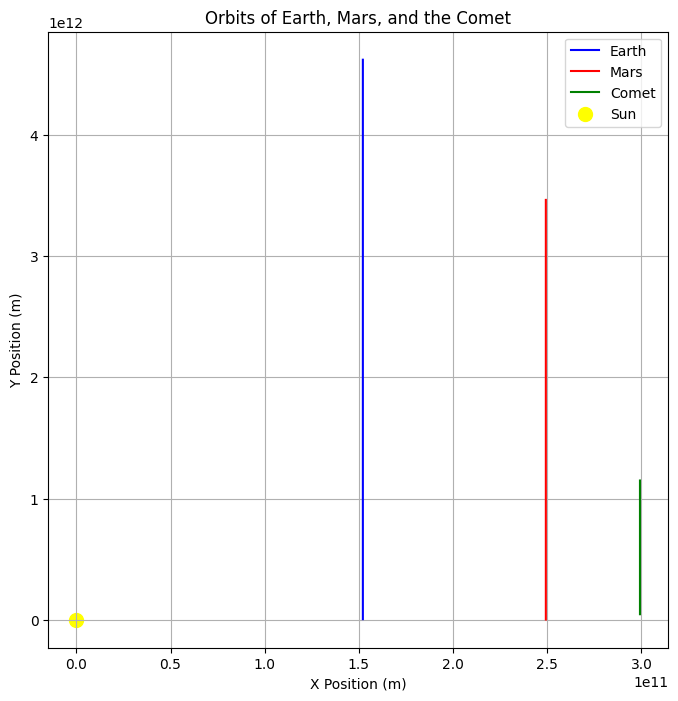

In [29]:
# Your code here 
plt.figure(figsize=(8, 8))
#plot orbits
plt.plot(xe_list, ye_list, label='Earth', color='blue')
plt.plot(xm_list, ym_list, label='Mars', color='red')
plt.plot(xc_list, yc_list, label='Comet', color='green')

#sun as yellow pt
plt.scatter(xs_list[0], ys_list[0], label='Sun', color='yellow', s=100)  # s=100 to make it a point

#label axes
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Orbits of Earth, Mars, and the Comet")
plt.grid(True)
plt.legend()
plt.show()


Goal: Animate the Motion
* Create an animated visualization of planetary orbits.
* Track the motion of each body over time.

\
Follow the procedure from lecture. Here are some hints:
* Set the `x` and `y` limits to `-3 * AU` to `3 * AU`. \


* Unpack the lines for Earth, Mars, the commet. Example: 
  * `line_e = axplot([], [], '-g', lw=1)` \

  
* Unpack the points for Earth, Mars, the commet and the Sun. Example:
  * `point_e, = ax.plot([],[],'bo',markersize=4)` \

* Give a title to each of the objects. Example:
  * `text_e  = ax.text(AU,0,'Earth')`

* Create the `update` function and update the lines, points and text you just unpacked. Example:
  * `line_e.set_data(xelist[:i], yelist[:i])` 
  * `point_e.set_data(xelist[i], yelist[i])`\
  * `text_e.set_position((xelist[i],yelist[i]))`


* Create the animation! Set `frames = len(xelist)`, `interval=1` and `blit=True`. 

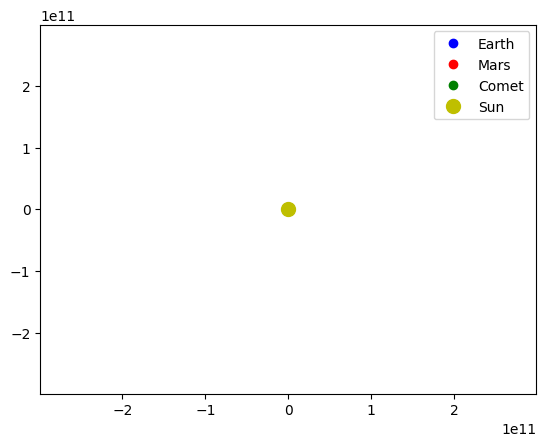

In [38]:
# Set up plot for animation
fig, ax = plt.subplots()
ax.set_xlim(-2 * AU, 2 * AU)
ax.set_ylim(-2 * AU, 2 * AU)

# Initialize the plot objects for the Earth, Mars, and Comet
point_e, = ax.plot([], [], 'bo', label='Earth')
text_e = ax.text(0, 0, '', color='blue')

point_m, = ax.plot([], [], 'ro', label='Mars')
text_m = ax.text(0, 0, '', color='red')

point_c, = ax.plot([], [], 'go', label='Comet')
text_c = ax.text(0, 0, '', color='green')

# Initialize the Sun (not animated)
ax.plot(xs_list[0], ys_list[0], 'yo', label='Sun', markersize=10)

# Update function for the animation
def update(i):
    # Update Earth
    point_e.set_data([xe_list[i]], [ye_list[i]])
    text_e.set_position((xe_list[i], ye_list[i]))

    # Update Mars
    point_m.set_data([xm_list[i]], [ym_list[i]])
    text_m.set_position((xm_list[i], ym_list[i]))

    # Update Comet
    point_c.set_data([xc_list[i]], [yc_list[i]])
    text_c.set_position((xc_list[i], yc_list[i]))

    return point_e, text_e, point_m, text_m, point_c, text_c

#create animation
ani = FuncAnimation(fig, update, frames=len(xe_list), repeat=False)
# Show the plot
plt.legend()

plt.show()


## 3.4 Add Mercury, Venus and the Moon!
As an extra challenge, give your best attempt at simulating Mercury, Venus and/or the Moon! I am not going to give you a ton of hints for this problem. Come to office hours if you have questions :)

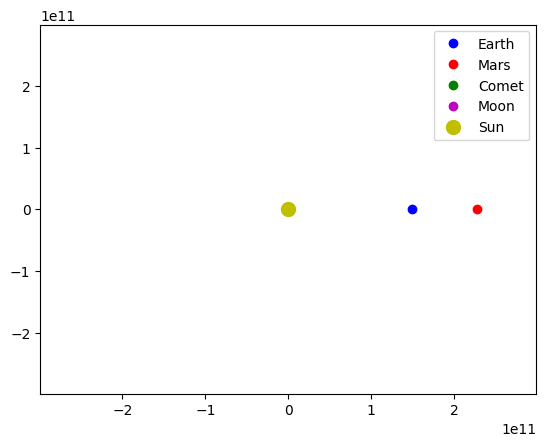

In [40]:
# Your code here
#moon const
Moon_distance = 0.00257 * AU  #distance between Earth and Moon in AU
Moon_velocity = 1.022 * 1000  #speed of Moon in m/s (around Earth)

#set up initial positions and velocities
xEarth, yEarth, zEarth = xe, ye, 0  # Position of Earth (already defined)
xMoon, yMoon, zMoon = xe + Moon_distance, ye, 0  #initial position of Moon (orbiting Earth)
xvMoon, yvMoon, zvMoon = 0, Moon_velocity, 0  #mvelocity of Moon

#store pos
moon_x_list = [xMoon]
moon_y_list = [yMoon]

#plots
fig, ax = plt.subplots()
ax.set_xlim(-2 * AU, 2 * AU)
ax.set_ylim(-2 * AU, 2 * AU)

point_e, = ax.plot([], [], 'bo', label='Earth')
text_e = ax.text(0, 0, '', color='blue')

point_m, = ax.plot([], [], 'ro', label='Mars')
text_m = ax.text(0, 0, '', color='red')

point_c, = ax.plot([], [], 'go', label='Comet')
text_c = ax.text(0, 0, '', color='green')

point_moon, = ax.plot([], [], 'mo', label='Moon')  # Moon plot

#sun
ax.plot(xs_list[0], ys_list[0], 'yo', label='Sun', markersize=10)

# Update function for the animation
def update(i):
    # Update Earth
    point_e.set_data([xe_list[i]], [ye_list[i]])
    text_e.set_position((xe_list[i], ye_list[i]))

    # Update Mars
    point_m.set_data([xm_list[i]], [ym_list[i]])
    text_m.set_position((xm_list[i], ym_list[i]))

    # Update Comet
    point_c.set_data([xc_list[i]], [yc_list[i]])
    text_c.set_position((xc_list[i], yc_list[i]))

    # Update Moon's position (orbiting Earth)
    global xMoon, yMoon, xvMoon, yvMoon

    #moon
    xMoon += xvMoon * dt
    yMoon += yvMoon * dt
    moon_x_list.append(xMoon)
    moon_y_list.append(yMoon)

    #update
    point_moon.set_data([xMoon], [yMoon])

    return point_e, text_e, point_m, text_m, point_c, text_c, point_moon

# Create the animation
ani = FuncAnimation(fig, update, frames=len(xe_list), repeat=False)
ani.save("planet_moon_animation.gif", writer="pillow")
# Show the plot
plt.legend()
plt.show()

Save you animation as a `.gif` or as a `.mp4`. Include this in your submission! This may take up to a couple mintutes!

In [ ]:
# Your code here
anim.save("animation.mp4", writer="ffmpeg", fps=20)

Upload this notebook and your animations to Gradescope!